# **Project Overview**

Credit risk analysis plays a vital role in the finance industry, as financial institutions must evaluate the creditworthiness of individuals and businesses before approving loans or credit lines. Traditional methods often rely on manually reviewing credit reports, financial statements, and other documents, making the process time-consuming, costly, and prone to errors. By leveraging machine learning, institutions can automate credit risk analysis, enhancing both efficiency and accuracy.


# **Data Understanding**

Data Source: https://www.kaggle.com/datasets/ranadeep/credit-risk-dataset/data

This is a credit history of the customers from a financial institution. Agenda is to predict for possible credit defaulters upfront and help the financial institutions to take steps accordingly.

    1-The dataset has 887,379 rows and 73 columns.
    2-There are 50 numerical columns and 23 categorical columns.
    3-Approximately 20 columns have missing values greater than 70%.
    4-The average budgeted amount is nearly equal to the amount borrowed.
    5-The average loan interest rate is 13.24%, which is quite large.
    6-There are 5 columns in date format, which are 'issue_d', 'last_pymnt_d','next_pymnt_d' earliest_cr_line', and last_credit_pull_d'.

# **<span>1.Loading the Dataset</span>**

In [6]:
# Import essential libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display, Markdown

# Set Seaborn style for better visuals
sns.set_style('whitegrid')

# Scikit-learn Preprocessing & Modeling
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split, GridSearchCV, RandomizedSearchCV
from sklearn import model_selection
from imblearn.over_sampling import SMOTE
from sklearn.cluster import KMeans
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.pipeline import Pipeline
from sklearn.metrics import classification_report, accuracy_score, f1_score

# Handle class imbalance
from imblearn.over_sampling import SMOTE

In [7]:
df_loan = pd.read_csv("loan.csv")
df_loan.head(5)

c:\Users\Ronnie\anaconda3\envs\learn-env\lib\site-packages\IPython\core\interactiveshell.py:3145: DtypeWarning: Columns (19,55) have mixed types.Specify dtype option on import or set low_memory=False.
  has_raised = await self.run_ast_nodes(code_ast.body, cell_name,


,id,member_id,loan_amnt,funded_amnt,funded_amnt_inv,term,int_rate,installment,grade,sub_grade,...,total_bal_il,il_util,open_rv_12m,open_rv_24m,max_bal_bc,all_util,total_rev_hi_lim,inq_fi,total_cu_tl,inq_last_12m
0,1077501,1296599,5000.0,5000.0,4975.0,36 months,10.65,162.87,B,B2,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,1077430,1314167,2500.0,2500.0,2500.0,60 months,15.27,59.83,C,C4,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,1077175,1313524,2400.0,2400.0,2400.0,36 months,15.96,84.33,C,C5,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,1076863,1277178,10000.0,10000.0,10000.0,36 months,13.49,339.31,C,C1,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,1075358,1311748,3000.0,3000.0,3000.0,60 months,12.69,67.79,B,B5,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [8]:
df_loan.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 887379 entries, 0 to 887378
Data columns (total 74 columns):
 #   Column                       Non-Null Count   Dtype  
---  ------                       --------------   -----  
 0   id                           887379 non-null  int64  
 1   member_id                    887379 non-null  int64  
 2   loan_amnt                    887379 non-null  float64
 3   funded_amnt                  887379 non-null  float64
 4   funded_amnt_inv              887379 non-null  float64
 5   term                         887379 non-null  object 
 6   int_rate                     887379 non-null  float64
 7   installment                  887379 non-null  float64
 8   grade                        887379 non-null  object 
 9   sub_grade                    887379 non-null  object 
 10  emp_title                    835917 non-null  object 
 11  emp_length                   842554 non-null  object 
 12  home_ownership               887379 non-null  object 
 13 

# **<span>2. Removing Irrelevant coloumn</span>**

In [9]:
df_loan.drop(df_loan.columns.difference(['loan_amnt','term','int_rate','installment','grade','emp_length','home_ownership',
                                         'annual_inc','verification_status','loan_status','purpose',]), 1, inplace=True)

In [10]:
df_loan.isnull().sum()

loan_amnt                  0
term                       0
int_rate                   0
installment                0
grade                      0
emp_length             44825
home_ownership             0
annual_inc                 4
verification_status        0
loan_status                0
purpose                    0
dtype: int64

There are many "Missing Values" in Column "emp_length" and few in "annual_inc".

In [11]:
df_loan.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 887379 entries, 0 to 887378
Data columns (total 11 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   loan_amnt            887379 non-null  float64
 1   term                 887379 non-null  object 
 2   int_rate             887379 non-null  float64
 3   installment          887379 non-null  float64
 4   grade                887379 non-null  object 
 5   emp_length           842554 non-null  object 
 6   home_ownership       887379 non-null  object 
 7   annual_inc           887375 non-null  float64
 8   verification_status  887379 non-null  object 
 9   loan_status          887379 non-null  object 
 10  purpose              887379 non-null  object 
dtypes: float64(4), object(7)
memory usage: 74.5+ MB


In [12]:
df_loan.head(10)

,loan_amnt,term,int_rate,installment,grade,emp_length,home_ownership,annual_inc,verification_status,loan_status,purpose
0,5000.0,36 months,10.65,162.87,B,10+ years,RENT,24000.0,Verified,Fully Paid,credit_card
1,2500.0,60 months,15.27,59.83,C,< 1 year,RENT,30000.0,Source Verified,Charged Off,car
2,2400.0,36 months,15.96,84.33,C,10+ years,RENT,12252.0,Not Verified,Fully Paid,small_business
3,10000.0,36 months,13.49,339.31,C,10+ years,RENT,49200.0,Source Verified,Fully Paid,other
4,3000.0,60 months,12.69,67.79,B,1 year,RENT,80000.0,Source Verified,Current,other
5,5000.0,36 months,7.90,156.46,A,3 years,RENT,36000.0,Source Verified,Fully Paid,wedding
6,7000.0,60 months,15.96,170.08,C,8 years,RENT,47004.0,Not Verified,Current,debt_consolidation
7,3000.0,36 months,18.64,109.43,E,9 years,RENT,48000.0,Source Verified,Fully Paid,car
8,5600.0,60 months,21.28,152.39,F,4 years,OWN,40000.0,Source Verified,Charged Off,small_business
9,5375.0,60 months,12.69,121.45,B,< 1 year,RENT,15000.0,Verified,Charged Off,other


In [13]:
df_loan.annual_inc = df_loan.annual_inc.fillna(0)
df_loan.isnull().sum()

loan_amnt                  0
term                       0
int_rate                   0
installment                0
grade                      0
emp_length             44825
home_ownership             0
annual_inc                 0
verification_status        0
loan_status                0
purpose                    0
dtype: int64

- to eliminate null values, the annual income column is filled with the value 0

# **<span>3. Create label Coloumn : Description about loan status</span>**

- In this column, the value 0 will be filled with the correct conditions: 'Fully Paid', 'Does not meet the credit policy. Status:Fully Paid', 'Current'
- Meanwhile, the value of 1 will be filled with incorrect conditions: 'Late (31-120 days)', 'Late (16-30 days)', 'In Grace Period', 'Charged Off', 'Default', 'Does not meet the credit policy. Status:Charged Off'

In [14]:
# binary classification
label_categories = [
    (0, ['Fully Paid', 'Does not meet the credit policy. Status:Fully Paid', 'Current']),
    (1, ['Late (31-120 days)', 'Late (16-30 days)', 'In Grace Period', 
         'Charged Off', 'Default', 'Does not meet the credit policy. Status:Charged Off'])
]

# function to apply the transformation
def classify_label(text):
    for category, matches in label_categories:
        if any(match in text for match in matches):
            return category
    return None

df_loan.loc[:, 'label'] = df_loan['loan_status'].apply(classify_label)
df_loan = df_loan.drop('loan_status', axis=1)

In [15]:
# label several label with specific grading system.
def SC_LabelEncoder1(text):
    if text == "E":
        return 1
    elif text == "D":
        return 2
    elif text == "C":
        return 3
    elif text == "B":
        return 4
    elif text == "A":
        return 5
    else:
        return 0
    
    
def SC_LabelEncoder2(text):
    if text == "< 1 year":
        return 1
    elif text == "1 year":
        return 2
    elif text == "2 years":
        return 3
    elif text == "3 years":
        return 4
    elif text == "4 years":
        return 5
    elif text == "5 years":
        return 6
    elif text == "6 years":
        return 7
    elif text == "7 years":
        return 8
    elif text == "8 years":
        return 9
    elif text == "9 years":
        return 10
    elif text == "10 years":
        return 11
    elif text == "10+ years":
        return 12
    else:
        return 0

def SC_LabelEncoder3(text):
    if text == "RENT":
        return 1
    elif text == "MORTGAGE":
        return 2
    elif text == "OWN":
        return 3
    else:
        return 0
    
df_loan["grade"] = df_loan["grade"].apply(SC_LabelEncoder1)
df_loan["emp_length"] = df_loan["emp_length"].apply(SC_LabelEncoder2)
df_loan["home_ownership"] = df_loan["home_ownership"].apply(SC_LabelEncoder3)

In [16]:
df_loan.head(10)

,loan_amnt,term,int_rate,installment,grade,emp_length,home_ownership,annual_inc,verification_status,purpose,label
0,5000.0,36 months,10.65,162.87,4,12,1,24000.0,Verified,credit_card,0.0
1,2500.0,60 months,15.27,59.83,3,1,1,30000.0,Source Verified,car,1.0
2,2400.0,36 months,15.96,84.33,3,12,1,12252.0,Not Verified,small_business,0.0
3,10000.0,36 months,13.49,339.31,3,12,1,49200.0,Source Verified,other,0.0
4,3000.0,60 months,12.69,67.79,4,2,1,80000.0,Source Verified,other,0.0
5,5000.0,36 months,7.90,156.46,5,4,1,36000.0,Source Verified,wedding,0.0
6,7000.0,60 months,15.96,170.08,3,9,1,47004.0,Not Verified,debt_consolidation,0.0
7,3000.0,36 months,18.64,109.43,1,10,1,48000.0,Source Verified,car,0.0
8,5600.0,60 months,21.28,152.39,0,5,3,40000.0,Source Verified,small_business,1.0
9,5375.0,60 months,12.69,121.45,4,1,1,15000.0,Verified,other,1.0


In [17]:
df_loan.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 887379 entries, 0 to 887378
Data columns (total 11 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   loan_amnt            887379 non-null  float64
 1   term                 887379 non-null  object 
 2   int_rate             887379 non-null  float64
 3   installment          887379 non-null  float64
 4   grade                887379 non-null  int64  
 5   emp_length           887379 non-null  int64  
 6   home_ownership       887379 non-null  int64  
 7   annual_inc           887379 non-null  float64
 8   verification_status  887379 non-null  object 
 9   purpose              887379 non-null  object 
 10  label                878919 non-null  float64
dtypes: float64(5), int64(3), object(3)
memory usage: 74.5+ MB


# **<span>4. Exploratory Data Analysis</span>**

Text(0.5, 1.0, 'Grade Distribution with loan_status')

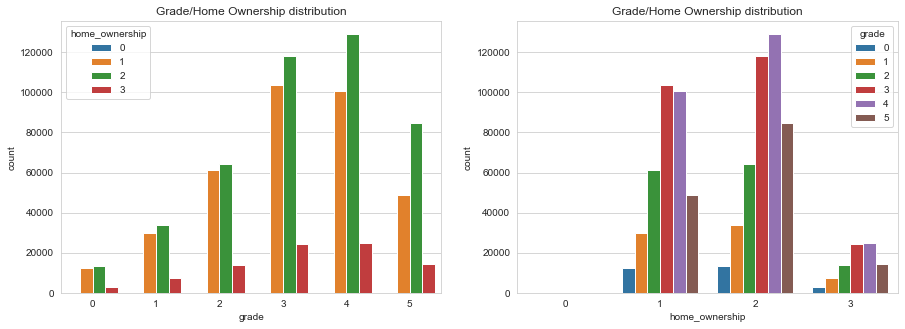

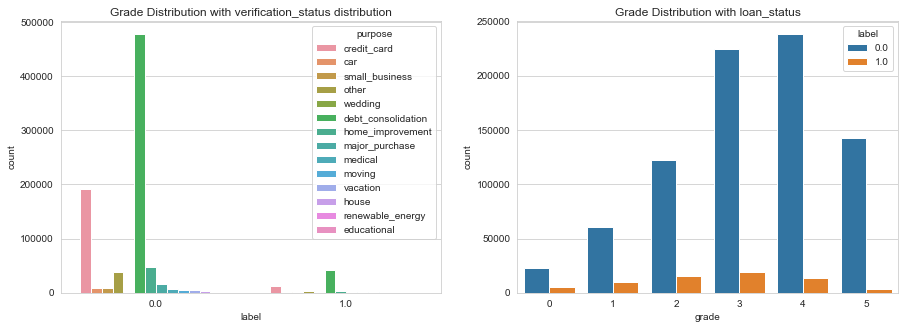

In [18]:
#These visualizations help analyze how different categorical variables (like grade, home_ownership, purpose, and label) interact.

fig, ax = plt.subplots(1,2,figsize=(15,5))
sns.countplot(data=df_loan, x='grade', hue="home_ownership", ax=ax[0]).set_title("Grade/Home Ownership distribution")
sns.countplot(data=df_loan, x='home_ownership', hue='grade', ax=ax[1]).set_title("Grade/Home Ownership distribution")

fig, ax = plt.subplots(1,2,figsize=(15,5))
sns.countplot(data=df_loan, x='label', hue='purpose', ax=ax[0]).set_title("Grade Distribution with verification_status distribution")
sns.countplot(data=df_loan, x='grade', hue='label', ax=ax[1]).set_title("Grade Distribution with loan_status")

### Observation :
1. The number of Borrowers with high grade will be small compared to low grade
2. Most money borrowers' goals from labels 0 and 1 are debt consolidation
3. The highest number of grades who were able to complete the loan was grade 4, while the most failed to complete the loan was grade 3

Text(0.5, 1.0, 'Loan amounts grouped by purpose')

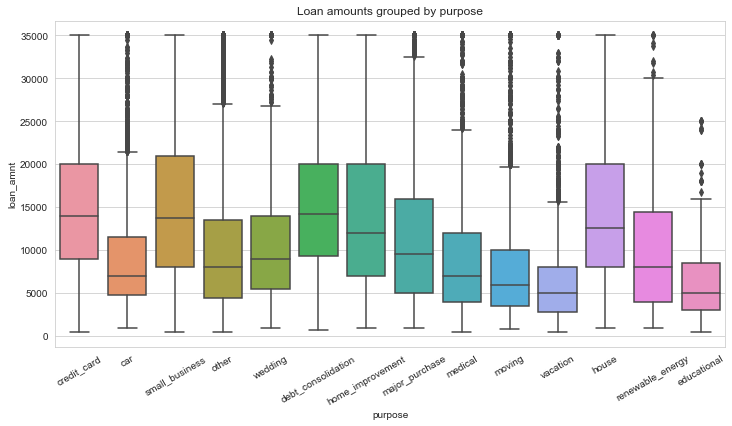

In [19]:
#visualize the distribution of loan amounts (loan_amnt) for different loan purposes (purpose) using a boxplot

plt.figure(figsize=(12,6))
sns.boxplot(x='purpose', y='loan_amnt', data=df_loan)
plt.xticks(rotation=30)
plt.title('Loan amounts grouped by purpose')

### Observation :
There are 5 highest categories for the amount of credit with the following purposes: Credit card, MSME business, debt consolidation, home improvement, and buying a house

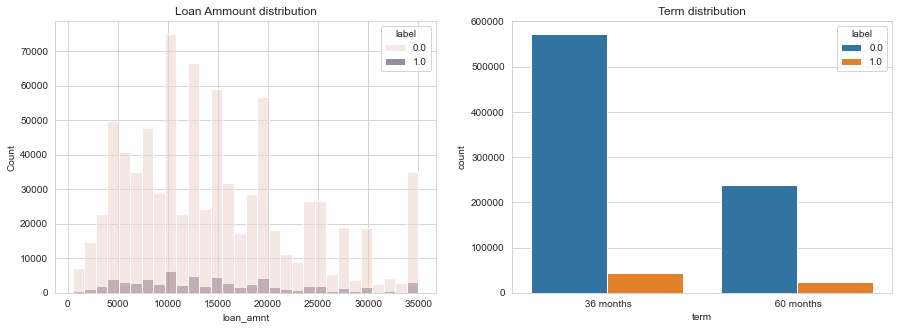

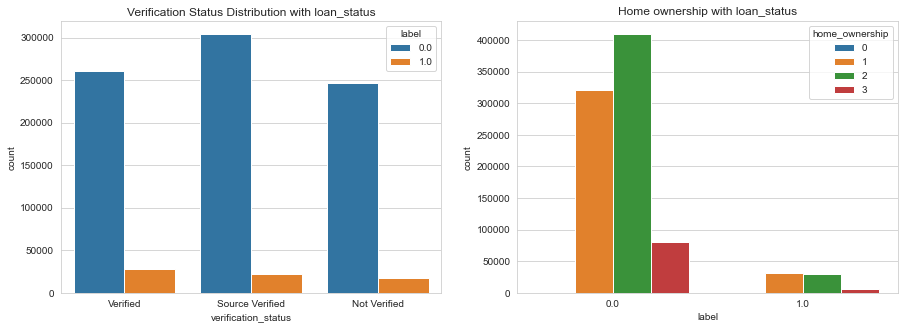

In [20]:
#two sets of subplots using Matplotlib and Seaborn to visualize different distributions in the df_loan dataset

fig, ax = plt.subplots(1,2,figsize=(15,5))
sns.histplot(df_loan, x='loan_amnt',hue="label", bins=30, ax=ax[0]).set_title("Loan Ammount distribution");
sns.countplot(data=df_loan, x='term', hue="label", ax=ax[1]).set_title("Term distribution");

fig, ax = plt.subplots(1,2,figsize=(15,5))
sns.countplot(data=df_loan, hue='home_ownership', x='label', ax=ax[1]).set_title("Home ownership with loan_status");
sns.countplot(data=df_loan, x='verification_status', hue='label', ax=ax[0]).set_title("Verification Status Distribution with loan_status");

### Observation:
1. The nominal value of the largest debt is 10000 USD
2. The maximum maturity is 36 months, while for 60 months it is almost a third
3. Most of the credits that can be paid in full are obtained from the "Verified" verification status

- Seeing the correlation between variables:

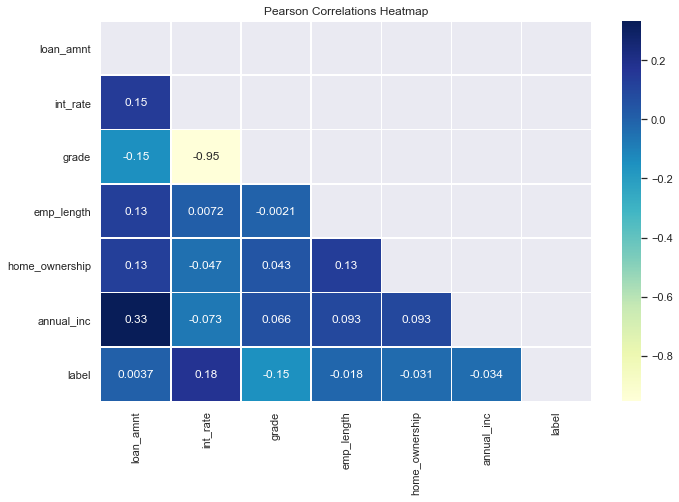

In [21]:
#A heatmap using Seaborn to visualize the Pearson correlation coefficients between selected numerical variables in the df_loan dataset.

corr = df_loan[['loan_amnt', 'int_rate', 'grade', 'emp_length', 'home_ownership', 'annual_inc','purpose','label']].corr()
sns.set(rc={'figure.figsize':(11,7)})
sns.heatmap(corr,linewidths=.5, annot=True, cmap="YlGnBu",mask=np.triu(np.ones_like(corr, dtype=np.bool)))\
    .set_title("Pearson Correlations Heatmap");

### Observation:
The amount of credit is very dependent on the annual income of the borrower

# **<span>5. Pra-Processing data for Discrete Coloumn</span>**

In [22]:
# use LabelEncoder() to encode another category column:
for col in ["verification_status", "purpose","term"]:
    le = LabelEncoder()
    le.fit(df_loan[col])
    df_loan[col] = le.transform(df_loan[col])
df_loan.head()

,loan_amnt,term,int_rate,installment,grade,emp_length,home_ownership,annual_inc,verification_status,purpose,label
0,5000.0,0,10.65,162.87,4,12,1,24000.0,2,1,0.0
1,2500.0,1,15.27,59.83,3,1,1,30000.0,1,0,1.0
2,2400.0,0,15.96,84.33,3,12,1,12252.0,0,11,0.0
3,10000.0,0,13.49,339.31,3,12,1,49200.0,1,9,0.0
4,3000.0,1,12.69,67.79,4,2,1,80000.0,1,9,0.0


In [23]:
df_loan.isnull().sum()

loan_amnt                 0
term                      0
int_rate                  0
installment               0
grade                     0
emp_length                0
home_ownership            0
annual_inc                0
verification_status       0
purpose                   0
label                  8460
dtype: int64

In [24]:
df_loan.label = df_loan.label.fillna(1)

# **<span>6. Clustering</span>**

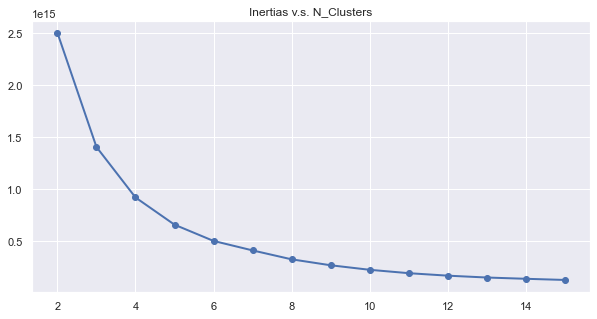

In [25]:
inertias = []

for i in range(2,16):
    kmeans = KMeans(n_clusters=i, random_state=0).fit(df_loan)
    inertias.append(kmeans.inertia_)

plt.figure(figsize=(10,5))
plt.title('Inertias v.s. N_Clusters')
plt.plot(np.arange(2,16),inertias, marker='o', lw=2);

### Observation: 
"Elbow" on the chart above is at 4. The number of clusters must be 4.

In [ ]:
# fit the KMeans model with the optimal number of clusters

km = KMeans(n_clusters=4, random_state=0)
clusters = km.fit_predict(df_loan)

<ipython-input-27-d611c00a7f93>:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_clustered["Cluster"] = clusters


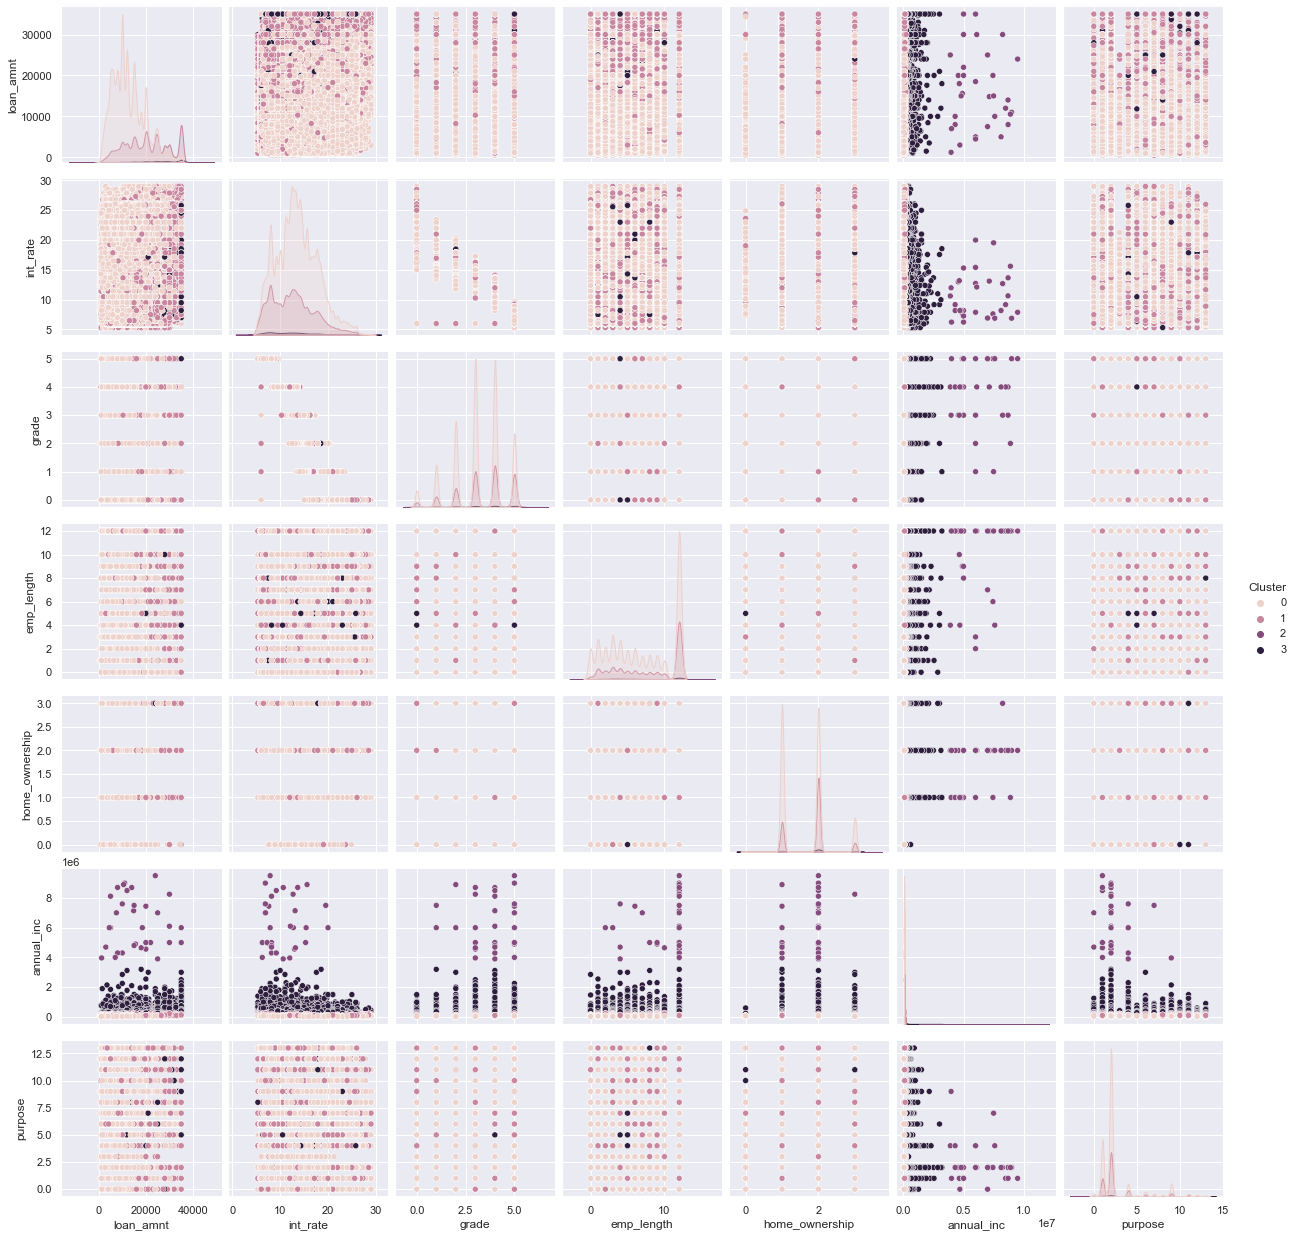

In [27]:
# visualize the clusters using a pairplot

df_clustered = df_loan[['loan_amnt', 'int_rate', 'grade', 'emp_length', 'home_ownership', 'annual_inc', 'purpose']]
df_clustered["Cluster"] = clusters
sns.pairplot(df_clustered[['loan_amnt', 'int_rate', 'grade', 'emp_length', 'home_ownership', 'annual_inc', 'purpose'
                           , "Cluster"]], hue="Cluster");

# **<span>7. Predicting Risk: Using the K-Nearest Neighbors Classification Model</span>**

In [28]:
#Define features (X) and target variable (y)
X, y = df_loan.drop("label", axis=1), df_loan["label"]

# Split the data into training (80%) and testing sets (20%)
X_train, X_test, y_train, y_test = model_selection.train_test_split(X, y, test_size=0.20, random_state=0)

In [29]:
# Optimizes the number of neighbors (k) for a k-Nearest Neighbors (KNN) classifier by testing different values and selecting the best one based on the F1-score.

max_score = 0
max_k = 0
for k in range(1, 100):
    neigh = KNeighborsClassifier(n_neighbors=k)
    neigh.fit(X_train,y_train)
    score = f1_score(y_test, neigh.predict(X_test),average='micro')
    if score > max_score:
        max_k = k
        max_score = score

In [30]:
print('If we use K-Nearest Neighbors Classification, then the value of K is',str(max_k),' to get the best prediction, then the average accuracy is ', max_score)

If we use K-Nearest Neighbors Classification, then the value of K is 30  to get the best prediction, then the average accuracy is  0.9142870021862111


## Classification with other ML models

Since K-Nearest Neighbors (KNN) classification requires significant time and memory for predictions, alternative machine learning models such as Support Vector Classifier (SVC), Decision Tree, Random Forest, and Gaussian Naïve Bayes can be considered.

However, in this notebook, we will focus on Decision Tree and Random Forest models.

Using Both DecisionTree Classifier and RandomForest

In [31]:
# Decision Tree Classifier
dt_classifier = DecisionTreeClassifier(random_state=0)
dt_classifier.fit(X_train, y_train)
y_pred_dt = dt_classifier.predict(X_test)
dt_accuracy = accuracy_score(y_test, y_pred_dt)
print("Decision Tree Classifier Accuracy: ", dt_accuracy)
print("Decision Tree Classifier Report:\n", classification_report(y_test, y_pred_dt))

# Random Forest Classifier
rf_classifier = RandomForestClassifier(random_state=0)
rf_classifier.fit(X_train, y_train)
y_pred_rf = rf_classifier.predict(X_test)
rf_accuracy = accuracy_score(y_test, y_pred_rf)
print("Random Forest Classifier Accuracy: ", rf_accuracy)
print("Random Forest Classifier Report:\n", classification_report(y_test, y_pred_rf))

# Insights and Recommendations
display(Markdown("""
## Insights:
1. **Decision Tree Classifier**:
    - Accuracy: {:.2f}%
    - The Decision Tree model provides a detailed classification report which helps in understanding the precision, recall, and F1-score for each class.

2. **Random Forest Classifier**:
    - Accuracy: {:.2f}%
    - The Random Forest model generally provides better accuracy and robustness compared to the Decision Tree model. It also helps in reducing overfitting.

## Recommendations:
1. **Model Selection**:
    - Based on the accuracy and classification report, the Random Forest model is recommended for predicting credit risk as it provides better accuracy and generalization.

2. **Feature Importance**:
    - Use the feature importance attribute of the Random Forest model to understand which features are most influential in predicting credit risk. This can help in feature selection and improving the model further.

3. **Hyperparameter Tuning**:
    - Perform hyperparameter tuning using techniques like Grid Search or Random Search to further improve the performance of the Random Forest model.

4. **Cross-Validation**:
    - Use cross-validation to ensure that the model's performance is consistent across different subsets of the data.

5. **Ensemble Methods**:
    - Consider using ensemble methods that combine multiple models to improve prediction accuracy and robustness.
""".format(dt_accuracy * 100, rf_accuracy * 100)))

Decision Tree Classifier Accuracy:  0.8475624873222295
Decision Tree Classifier Report:
               precision    recall  f1-score   support

         0.0       0.92      0.91      0.92    162264
         1.0       0.16      0.19      0.18     15212

    accuracy                           0.85    177476
   macro avg       0.54      0.55      0.55    177476
weighted avg       0.86      0.85      0.85    177476

Random Forest Classifier Accuracy:  0.9116387567896505
Random Forest Classifier Report:
               precision    recall  f1-score   support

         0.0       0.92      0.99      0.95    162264
         1.0       0.32      0.03      0.05     15212

    accuracy                           0.91    177476
   macro avg       0.62      0.51      0.50    177476
weighted avg       0.87      0.91      0.88    177476




## Insights:
1. **Decision Tree Classifier**:
    - Accuracy: 84.76%
    - The Decision Tree model provides a detailed classification report which helps in understanding the precision, recall, and F1-score for each class.

2. **Random Forest Classifier**:
    - Accuracy: 91.16%
    - The Random Forest model generally provides better accuracy and robustness compared to the Decision Tree model. It also helps in reducing overfitting.

## Recommendations:
1. **Model Selection**:
    - Based on the accuracy and classification report, the Random Forest model is recommended for predicting credit risk as it provides better accuracy and generalization.

2. **Feature Importance**:
    - Use the feature importance attribute of the Random Forest model to understand which features are most influential in predicting credit risk. This can help in feature selection and improving the model further.

3. **Hyperparameter Tuning**:
    - Perform hyperparameter tuning using techniques like Grid Search or Random Search to further improve the performance of the Random Forest model.

4. **Cross-Validation**:
    - Use cross-validation to ensure that the model's performance is consistent across different subsets of the data.

5. **Ensemble Methods**:
    - Consider using ensemble methods that combine multiple models to improve prediction accuracy and robustness.
